In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving bank-additional-full.csv to bank-additional-full.csv


In [3]:
import pandas as pd

df = pd.read_csv("bank-additional-full.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
# Check nulls
print(df.isnull().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert target column
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Rename target for clarity
df.rename(columns={'y':'subscription'}, inplace=True)

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  object 
 2   marital         41176 non-null  object 
 3   education       41176 non-null  object 
 4   default         41176 non-null  object 
 5   housing         41176 non-null  object 
 6   loan            41176 non-null  object 
 7   contact         41176 non-null  object 
 8   month           41176 non-null  object 
 9   day_of_week     41176 non-null  object 
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  pdays           41176 non-null  int64  
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  object 
 15  emp.var.rate    41176 non-null  float64
 16  cons.price.idx  41176 non-null  float64
 17  cons.conf.idx   41176 non-null  floa

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscription
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870,0.112663
std,10.42068,259.305321,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364,0.316184
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


In [19]:
df['contacted'] = 1
df['engaged'] = df['duration'] > 100
df['subscribed'] = df['subscription'] == 1

funnel = pd.DataFrame({
    "Stage": ["Contacted", "Engaged", "Subscribed"],
    "Count": [
        df['contacted'].sum(),
        df['engaged'].sum(),
        df['subscribed'].sum()
    ]
})

funnel

,Stage,Count
0,Contacted,41176
1,Engaged,31152
2,Subscribed,4639


In [20]:
channel_quality = df.groupby('contact').agg(
    total_leads=('subscription','count'),
    conversions=('subscription','sum')
)

channel_quality['conversion_rate'] = channel_quality['conversions'] / channel_quality['total_leads']

channel_quality.sort_values('conversion_rate', ascending=False)

,total_leads,conversions,conversion_rate
contact,,,
cellular,26135,3852,0.147389
telephone,15041,787,0.052324


In [21]:
df.groupby('subscription')['duration'].describe()

,count,mean,std,min,25%,50%,75%,max
subscription,,,,,,,,
0,36537.0,220.868079,207.116178,0.0,95.0,164.0,279.0,4918.0
1,4639.0,553.256090,401.190736,37.0,253.5,449.0,741.5,4199.0


In [22]:
campaign_effect = df.groupby('campaign').agg(
    total=('subscription','count'),
    conversions=('subscription','sum')
)

campaign_effect['conversion_rate'] = campaign_effect['conversions'] / campaign_effect['total']

campaign_effect.head(10)

,total,conversions,conversion_rate
campaign,,,
1,17634,2299,0.130373
2,10568,1211,0.114591
3,5340,574,0.107491
4,2650,249,0.093962
5,1599,120,0.075047
6,979,75,0.076609
7,629,38,0.060413
8,400,17,0.042500
9,283,17,0.060071


In [23]:
stage_table = pd.DataFrame({
    "Stage": ["Contacted", "Interested (duration>100)", "Subscribed"],
    "Count": [
        len(df),
        df[df['duration'] > 100].shape[0],
        df['subscription'].sum()
    ]
})

stage_table

,Stage,Count
0,Contacted,41176
1,Interested (duration>100),31152
2,Subscribed,4639


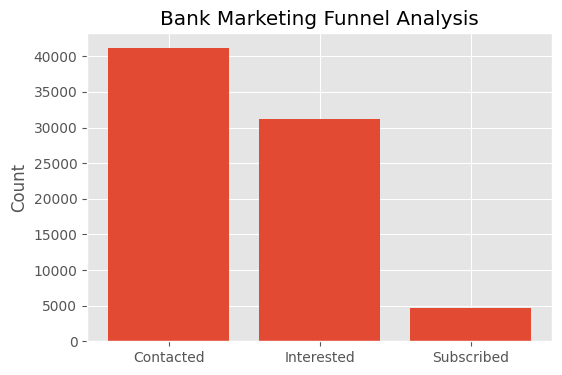

In [7]:
funnel = {
    "Contacted": df['contacted'].sum(),
    "Interested": df['interested'].sum(),
    "Subscribed": df['subscribed'].sum()
}

plt.figure(figsize=(6,4))
plt.bar(funnel.keys(), funnel.values())
plt.title("Bank Marketing Funnel Analysis")
plt.ylabel("Count")
plt.show()

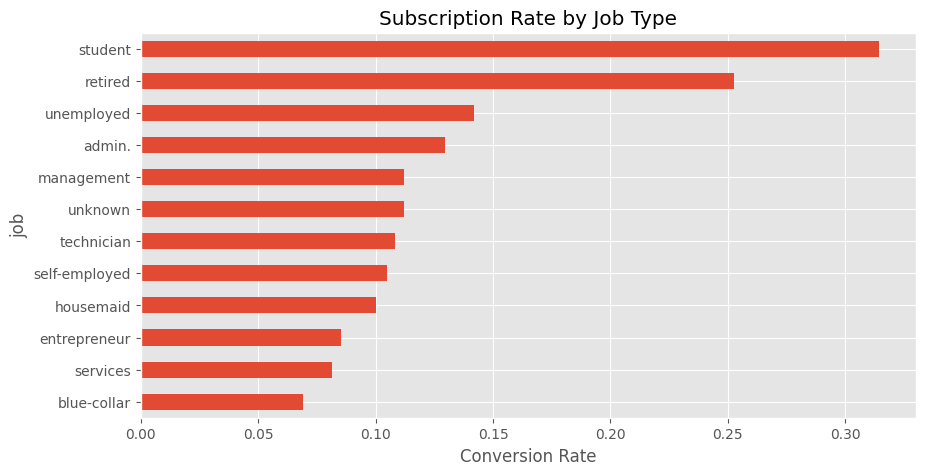

In [8]:
plt.figure(figsize=(10,5))

df.groupby('job')['subscription'].mean().sort_values().plot(kind='barh')
plt.title("Subscription Rate by Job Type")
plt.xlabel("Conversion Rate")
plt.show()

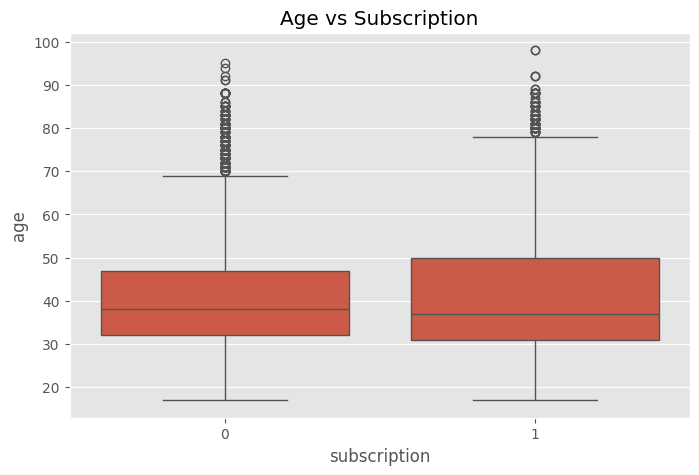

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x='subscription', y='age', data=df)
plt.title("Age vs Subscription")
plt.show()

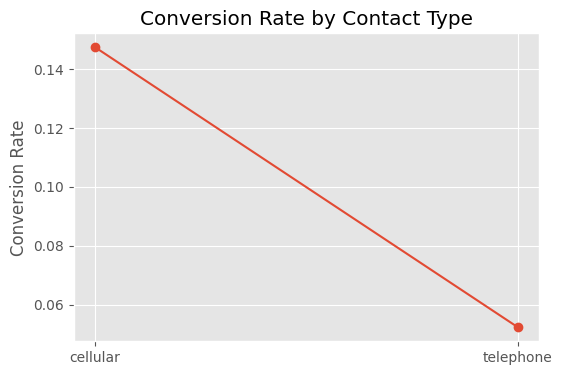

In [13]:
data = df.groupby('contact')['subscription'].mean()

plt.figure(figsize=(6,4))
plt.plot(data.index, data.values, marker='o')
plt.title("Conversion Rate by Contact Type")
plt.ylabel("Conversion Rate")
plt.show()

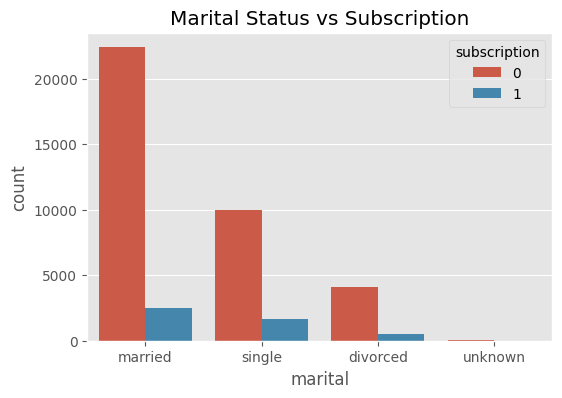

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='marital', hue='subscription', data=df)
plt.title("Marital Status vs Subscription")
plt.show()

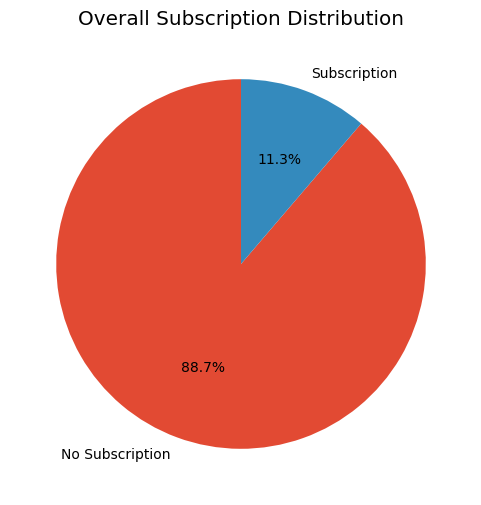

In [17]:
import matplotlib.pyplot as plt

data = df['subscription'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(data, labels=['No Subscription', 'Subscription'],
        autopct='%1.1f%%', startangle=90)
plt.title("Overall Subscription Distribution")
plt.show()

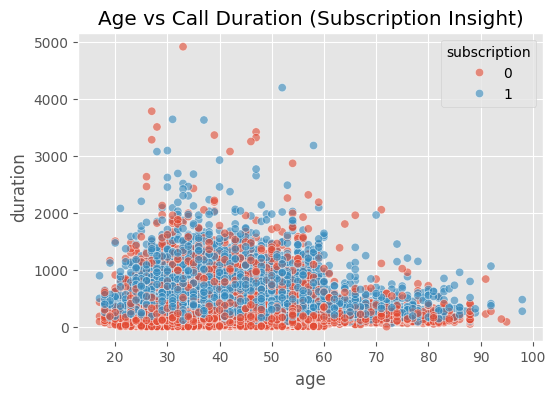

In [16]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='duration', hue='subscription', data=df, alpha=0.6)
plt.title("Age vs Call Duration (Subscription Insight)")
plt.show()

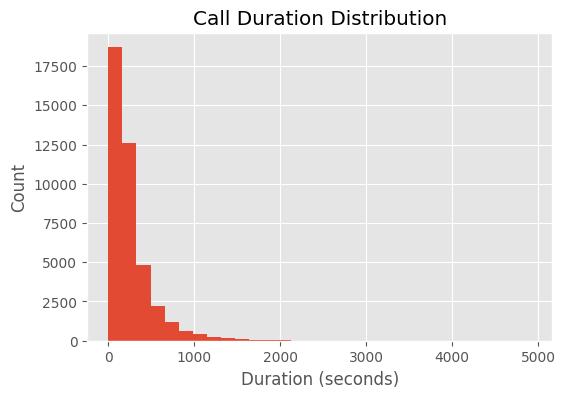

In [18]:
plt.figure(figsize=(6,4))
plt.hist(df['duration'], bins=30)
plt.title("Call Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.show()

**KEY INSIGHTS**

 Overall conversion rate is very low compared to total contacts, showing strong drop-off in the funnel.

 Longer call duration is strongly associated with higher chances of subscription.

 Middle-aged customers show higher conversion compared to younger and older groups.

 Certain job categories (like management and technician) contribute more to successful conversions.


 **BUSINESS RECOMMENDATIONS**

 Focus on improving call quality and engagement rather than increasing number of calls.

 Prioritize leads with higher interaction time (long-duration calls).

 Target high-performing customer segments (job roles and age groups with better conversion).

 Reduce repeated and unnecessary campaign contacts to improve efficiency and reduce cost.